#### Reference Hamiltonian

#### Import

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import (
    EffectiveInteractionOptimizer,
    EffectiveInteractionOptimizer2ndVersion,
)
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


##### Parameters

In [2]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
logical_qubits = 6

g_onebody = {}
diagonal_elements = np.zeros(logical_qubits)
g_matrix = np.zeros((logical_qubits, logical_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]


# get the computational basis of the space
basis = computational_basis(logical_qubits)

In [3]:
hamiltonian_xy = 0.0
for i in range(logical_qubits):
    for j in range(i + 1, logical_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(logical_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=logical_qubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [4]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [5]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=logical_qubits).qutip_op
    for i in range(logical_qubits)
)
print(N_op.shape)

# shape (2**logical_qubits, logical_qubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(64, 64)
Ground state energy in N=1 sector: -11.93178825156149
Ground state in N=1 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
      000001    0.02453   -0.15662   -0.00000
      000010    0.02453    0.15662    0.00000
      000100    0.17485    0.41815    0.00000
      001000    0.25870    0.50862    0.00000
      010000    0.25870   -0.50862   -0.00000
      100000    0.25870    0.50862    0.00000


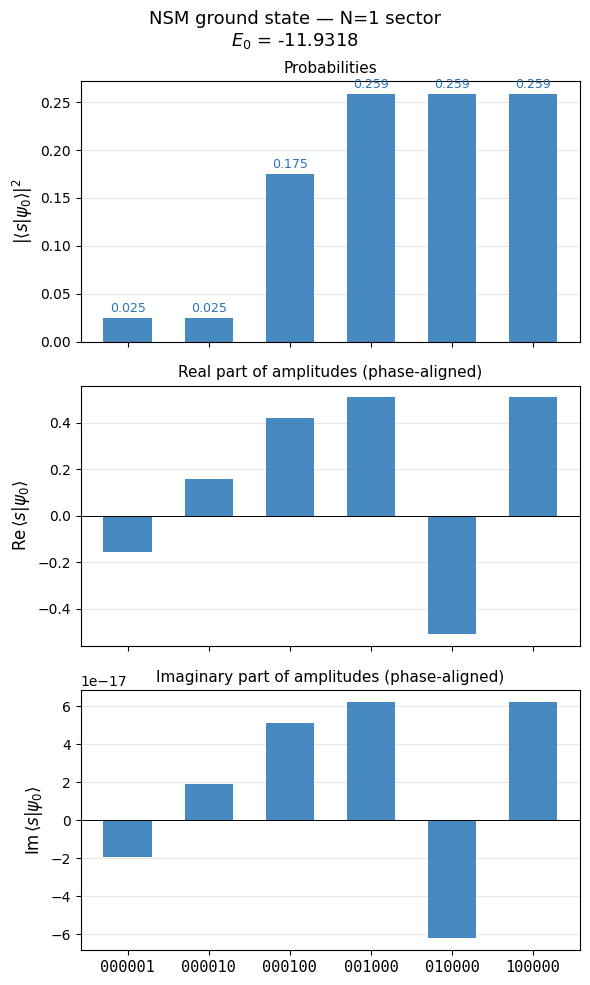

In [6]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(logical_qubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

#### Getting the freaking effective Interaction

Optimal drive parameters: [ 0.90513022 -1.02535362  0.96153052  0.79417758  1.10508836 -1.13502171]
Optimized effective interaction matrix:
 [[ 0.00000000e+00  2.38278548e-01 -4.64010327e-01  1.81947765e-01
   9.31196815e-01  4.25607481e-01]
 [ 2.38278548e-01  0.00000000e+00  1.26008803e-01 -8.64690287e-02
  -5.12897271e-04  2.35762769e-01]
 [-4.64010327e-01  1.26008803e-01  0.00000000e+00  1.37155908e-01
  -3.27870147e-01 -7.07116593e-01]
 [ 1.81947765e-01 -8.64690287e-02  1.37155908e-01  0.00000000e+00
  -1.59923015e-01  1.83695413e-01]
 [ 9.31196815e-01 -5.12897271e-04 -3.27870147e-01 -1.59923015e-01
   0.00000000e+00  3.53399276e-01]
 [ 4.25607481e-01  2.35762769e-01 -7.07116593e-01  1.83695413e-01
   3.53399276e-01  0.00000000e+00]]


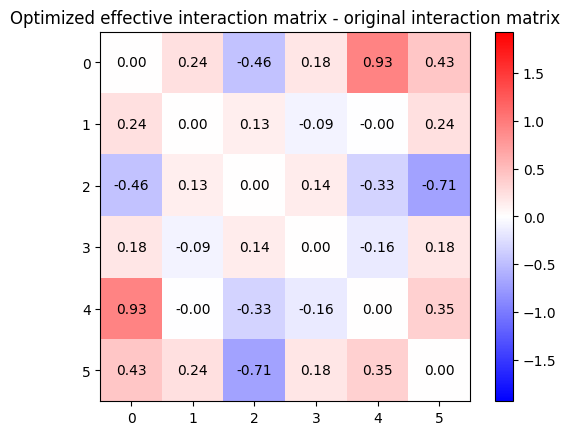

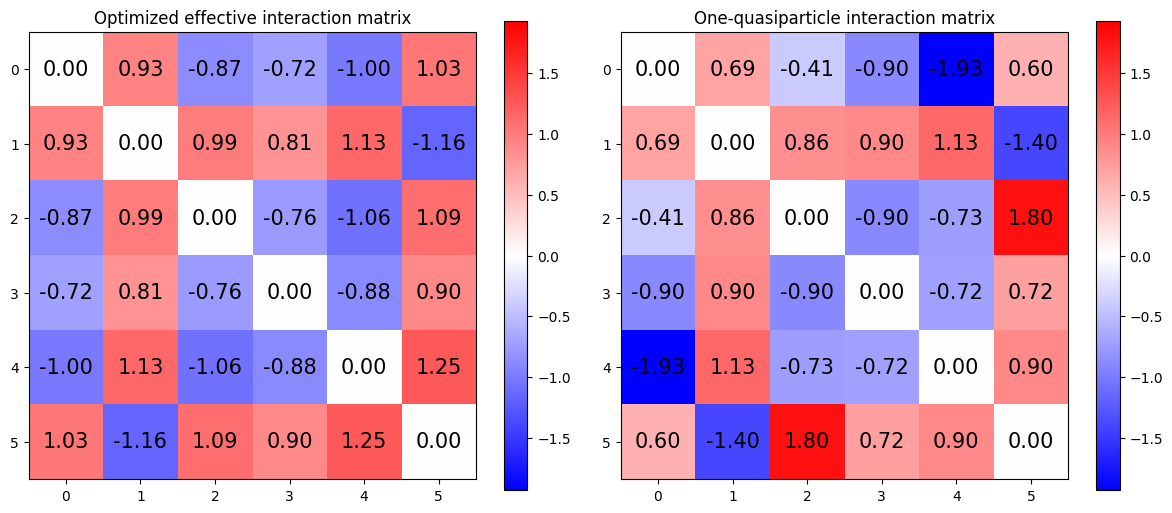

In [108]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=logical_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(logical_qubits):
    for j in range(logical_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(logical_qubits):
        for j in range(logical_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

Other type of effective interaction

In [110]:
opt = EffectiveInteractionOptimizer2ndVersion(logical_qubits)

# Stage 1 (uncomment to refit d from scratch instead of using a fixed d_star):
d_opt, res1 = opt.optimize_rank1(g_matrix)

# Stage 2: alpha_AB and c_AB on top of the fixed d_star
alpha_matrix, c_matrix, report, g_corrected = opt.get_alpha_and_c(g_matrix, d_opt)
opt.print_report(g_matrix, d_opt, alpha_matrix, c_matrix, report)

c_matrix[np.abs(c_matrix) > 4] = np.abs(c_matrix[np.abs(c_matrix) > 4])

d (fixed ansatz): [-0.9051  1.0254 -0.9615 -0.7942 -1.1051  1.135 ]
Rank-1-only loss: 2.242931e+00

  pair     target      rank1    alpha_AB        c_AB   pole?                          branch
----------------------------------------------------------------------------------------------------
  (0,1)     0.6898     0.9281      0.7433      1.0554          alpha<1 (shrink/flip vs rank-1)
  (0,2)    -0.4063    -0.8703      0.4668    -16.0807          alpha<1 (shrink/flip vs rank-1)
  (0,3)    -0.9008    -0.7188      1.2531     -0.3361               alpha>1 (boost vs rank-1)
  (0,4)    -1.9314    -1.0002      1.9310     -0.6506               alpha>1 (boost vs rank-1)
  (0,5)     0.6017     1.0273      0.5857      4.8329          alpha<1 (shrink/flip vs rank-1)
  (1,2)     0.8599     0.9859      0.8722      0.3434          alpha<1 (shrink/flip vs rank-1)
  (1,3)     0.9008     0.8143      1.1062     -0.1752               alpha>1 (boost vs rank-1)
  (1,4)     1.1336     1.1331      1.0005   

#### D-WAVE Embedding and effective Hamiltonians

In [111]:
import minorminer
import dwave_networkx as dnx
import networkx as nx

# K4: fully connected, 4 nodes = 6 edges
K4 = nx.complete_graph(logical_qubits)
print("Problem edges:", list(K4.edges()))

# Hardware graph
hardware = dnx.pegasus_graph(16)
# the library that creates embeddings
import minorminer

embedding = minorminer.find_embedding(K4, hardware)
# we get the embedding as a dictionary where the keys are the logical qubits
# and the values are lists of physical qubits (chains) in the hardware graph.


# Manual verification
def check_embedding(embedding, problem_graph, hardware_graph):
    # Check 1: all chains connected in hardware
    for node, chain in embedding.items():
        # I get the subgraph that connects all the physical qubits
        subgraph = hardware_graph.subgraph(chain)
        if not nx.is_connected(subgraph):
            print(f"✗ q{node}: chain {chain} is NOT connected in hardware")
            return False

    # Check 2: every problem edge has a coupler between chains
    for u, v in problem_graph.edges():
        chain_u = set(embedding[u])
        chain_v = set(embedding[v])
        has_coupler = any(
            hardware_graph.has_edge(a, b) for a in chain_u for b in chain_v
        )
        if not has_coupler:
            print(
                f"✗ edge ({u},{v}): no coupler between chains {chain_u} and {chain_v}"
            )
            return False

    print("✓ Valid embedding")
    print(f"  Chain lengths: { {f'q{k}': len(v) for k,v in embedding.items()} }")
    return True


check_embedding(embedding, K4, hardware)

Problem edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
✓ Valid embedding
  Chain lengths: {'q0': 1, 'q1': 2, 'q2': 1, 'q3': 2, 'q4': 1, 'q5': 1}


True

/tmp/ipykernel_390122/884035853.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


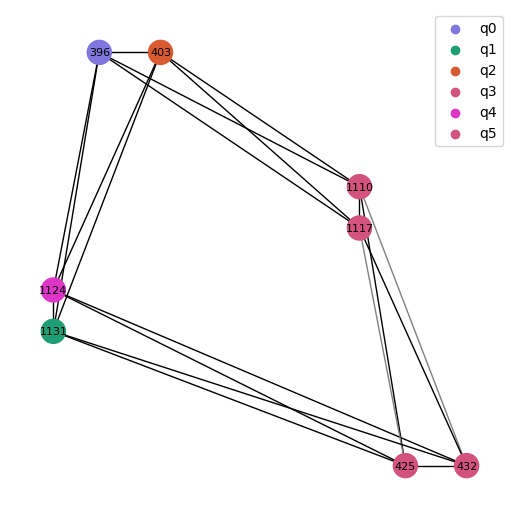

In [112]:
import matplotlib.pyplot as plt
import dwave_networkx as dnx
import minorminer
import networkx as nx

K4 = nx.complete_graph(logical_qubits)
hardware = dnx.pegasus_graph(8)
embedding = minorminer.find_embedding(K4, hardware)

# Extract only the hardware nodes/edges used
used_nodes = [node for chain in embedding.values() for node in chain]
used_edges = []
for u, v in K4.edges():
    for a in embedding[u]:
        for b in embedding[v]:
            if hardware.has_edge(a, b):
                used_edges.append((a, b))

# Color by logical qubit
colors = [
    "#7F77DD",
    "#1D9E75",
    "#D85A30",
    "#D4537E",
    "#DD36C7",
    "#D4537E",
]  # purple, teal, coral, pink
node_colors = {}
for i, chain in embedding.items():
    for node in chain:
        node_colors[node] = colors[i]

subgraph = hardware.subgraph(used_nodes).copy()
for u, v in used_edges:
    if not subgraph.has_edge(u, v):
        subgraph.add_edge(u, v)

pos = dnx.pegasus_layout(subgraph)

plt.figure(figsize=(5, 5))
nx.draw(
    subgraph,
    pos,
    node_color=[node_colors[n] for n in subgraph.nodes()],
    edge_color=[
        "gray" if (u, v) not in used_edges and (v, u) not in used_edges else "black"
        for u, v in subgraph.edges()
    ],
    node_size=300,
    with_labels=True,
    font_size=8,
)
plt.legend(handles=[plt.scatter([], [], c=colors[i], label=f"q{i}") for i in range(6)])
plt.tight_layout()
plt.savefig("embedding.png", dpi=150)
plt.show()

In [113]:
print(used_nodes)
print(used_edges)

# build index map: physical qubit → local index 0..7
phys_to_idx = {phys: idx for idx, phys in enumerate(used_nodes)}

print("=== Physical → Local index ===")
for phys, idx in phys_to_idx.items():
    print(f"  {phys} → {idx}")

print("\n=== Chains (local indices) ===")
mapping = []
for logical, chain in embedding.items():
    local_chain = [phys_to_idx[p] for p in chain]
    mapping.append(local_chain)
    print(f"  q{logical} → {local_chain}")

print("\n=== Edges (local indices) ===")
local_edges = [(phys_to_idx[u], phys_to_idx[v]) for u, v in used_edges]
print(local_edges)

[396, 1131, 403, 1117, 425, 1124, 1110, 432]
[(396, 1131), (396, 403), (396, 1117), (396, 1124), (396, 1110), (1131, 403), (1131, 425), (1131, 1124), (1131, 432), (403, 1117), (403, 1124), (403, 1110), (425, 1124), (1117, 1110), (1117, 432), (425, 1110), (425, 432), (1124, 432)]
=== Physical → Local index ===
  396 → 0
  1131 → 1
  403 → 2
  1117 → 3
  425 → 4
  1124 → 5
  1110 → 6
  432 → 7

=== Chains (local indices) ===
  q0 → [0]
  q1 → [1]
  q2 → [2]
  q3 → [3, 4]
  q4 → [5]
  q5 → [6, 7]

=== Edges (local indices) ===
[(0, 1), (0, 2), (0, 3), (0, 5), (0, 6), (1, 2), (1, 4), (1, 5), (1, 7), (2, 3), (2, 5), (2, 6), (4, 5), (3, 6), (3, 7), (4, 6), (4, 7), (5, 7)]


Encoding

In [114]:
# chains dict: already comes from embedding + phys_to_idx
chains = {
    logical: [phys_to_idx[p] for p in chain] for logical, chain in embedding.items()
}

# intra_edges: pairs within the same chain that are connected in hardware
intra_edges = []
for logical, chain in chains.items():
    local_chain = [phys_to_idx[p] for p in embedding[logical]]
    for k in range(len(local_chain) - 1):
        intra_edges.append((local_chain[k], local_chain[k + 1]))

# inter_edges: all local_edges minus intra_edges
intra_set = set(map(frozenset, intra_edges))
inter_edges = [(u, v) for u, v in local_edges if frozenset((u, v)) not in intra_set]

print("Chains:", chains)
print("Intra edges:", intra_edges)
print("Inter edges:", inter_edges)
print("Representatives:", {l: chain[0] for l, chain in chains.items()})

Chains: {0: [0], 1: [1], 2: [2], 3: [3, 4], 4: [5], 5: [6, 7]}
Intra edges: [(3, 4), (6, 7)]
Inter edges: [(0, 1), (0, 2), (0, 3), (0, 5), (0, 6), (1, 2), (1, 4), (1, 5), (1, 7), (2, 3), (2, 5), (2, 6), (4, 5), (3, 6), (3, 7), (4, 6), (4, 7), (5, 7)]
Representatives: {0: 0, 1: 1, 2: 2, 3: 3, 4: 5, 5: 6}


In [115]:
# physical qubit -> logical qubit lookup
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

In [116]:
# for each logical pair, find the physical coupler
logical_pair_to_physical_coupler = {}
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in logical_pair_to_physical_coupler:
        logical_pair_to_physical_coupler[pair] = (u, v)

print("=== Logical pair → physical coupler ===")
for pair, (u, v) in logical_pair_to_physical_coupler.items():
    lu, lv = tuple(pair)
    print(f"  q{lu}-q{lv}: physical ({u},{v})")

=== Logical pair → physical coupler ===
  q0-q1: physical (0,1)
  q0-q2: physical (0,2)
  q0-q3: physical (0,3)
  q0-q4: physical (0,5)
  q0-q5: physical (0,6)
  q1-q2: physical (1,2)
  q1-q3: physical (1,4)
  q1-q4: physical (1,5)
  q1-q5: physical (1,7)
  q2-q3: physical (2,3)
  q2-q4: physical (2,5)
  q2-q5: physical (2,6)
  q3-q4: physical (4,5)
  q3-q5: physical (3,6)
  q4-q5: physical (5,7)


In [117]:
print(c_matrix)

[[            nan  1.05544730e+00  1.60806689e+01 -3.36090850e-01
  -6.50585477e-01  4.83294793e+00]
 [ 1.05544730e+00             nan  3.43399147e-01 -1.75171329e-01
  -9.04474947e-04 -2.88337656e-01]
 [ 1.60806689e+01  3.43399147e-01             nan -2.64285410e-01
   1.61180542e+00 -5.64430936e-01]
 [-3.36090850e-01 -1.75171329e-01 -2.64285410e-01             nan
   5.73416189e-01  6.87974643e-01]
 [-6.50585477e-01 -9.04474947e-04  1.61180542e+00  5.73416189e-01
              nan  1.29095454e+00]
 [ 4.83294793e+00 -2.88337656e-01 -5.64430936e-01  6.87974643e-01
   1.29095454e+00             nan]]


In [133]:
import qutip as qt
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import numpy as np
from collections import defaultdict

gamma = 200
J_F = (gamma**2) / 0.01
n_physical = len(used_nodes)

N_tot = 1

identity = qt.tensor([qt.qeye(2)] * n_physical)

# build a lookup: physical qubit -> logical qubit
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        print(p, "p value in chain")
        phys_to_logical[p] = logical


# rebuild hamiltonian_zz using ONLY representatives

hamiltonian_zz = 0.0
added_pairs = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]

    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs:
        continue
    added_pairs.add(pair)
    # use the actual hardware coupler (u,v), not the representatives
    print(f"  logical (q{lu},q{lv}): physical coupler ({u},{v})")
    hamiltonian_zz += SpinOperator(
        [("qz", u, "qz", v)],
        coupling=[(2 + c_matrix[lu, lv]) * gamma],
        size=n_physical,
        verbose=0,
    ).qutip_op
    print(
        f"  logical (q{lu},q{lv}): coupler ({u},{v}), c={c_matrix[lu,lv]:.4f}, J={J_F:.4f}"
    )
print(f"ZZ pairs added: {len(added_pairs)}")

hamiltonian_z = 0.0
h_constraint = gamma * (1 - 2 * N_tot)


H_diagonal = 0.0
for logical, chain in chains.items():
    k = len(chain)
    print(f"Logical qubit {logical} has chain {chain} with length {k}")
    eps = h_constraint / len(chain) + diagonal_elements[logical] / (gamma * len(chain))
    for phys in chain:
        print(phys, eps)
        H_diagonal += SpinOperator(
            [("qz", phys)], coupling=[eps], size=n_physical
        ).qutip_op


H_ferro = 0.0
for a, b in intra_edges:
    H_ferro += SpinOperator(
        [("z", a, "z", b)], coupling=[-J_F], size=n_physical, verbose=0
    ).qutip_op


longitudinal_hamiltonian = (
    hamiltonian_zz
    + hamiltonian_z
    + gamma * (N_tot**2) * identity
    + H_ferro
    + H_diagonal
    + J_F * len(intra_edges) * identity
)

# check spectrum
evals = np.sort(np.real(longitudinal_hamiltonian.diag()))
print("Spectrum (first 8):", evals[:15])
print("Ground state degeneracy:", np.sum(np.isclose(evals, evals[0])))

0 p value in chain
1 p value in chain
2 p value in chain
3 p value in chain
4 p value in chain
5 p value in chain
6 p value in chain
7 p value in chain
  logical (q0,q1): physical coupler (0,1)
  logical (q0,q1): coupler (0,1), c=1.0554, J=4000000.0000
  logical (q0,q2): physical coupler (0,2)
  logical (q0,q2): coupler (0,2), c=16.0807, J=4000000.0000
  logical (q0,q3): physical coupler (0,3)
  logical (q0,q3): coupler (0,3), c=-0.3361, J=4000000.0000
  logical (q0,q4): physical coupler (0,5)
  logical (q0,q4): coupler (0,5), c=-0.6506, J=4000000.0000
  logical (q0,q5): physical coupler (0,6)
  logical (q0,q5): coupler (0,6), c=4.8329, J=4000000.0000
  logical (q1,q2): physical coupler (1,2)
  logical (q1,q2): coupler (1,2), c=0.3434, J=4000000.0000
  logical (q1,q3): physical coupler (1,4)
  logical (q1,q3): coupler (1,4), c=-0.1752, J=4000000.0000
  logical (q1,q4): physical coupler (1,5)
  logical (q1,q4): coupler (1,5), c=-0.0009, J=4000000.0000
  logical (q1,q5): physical coupler

In [126]:
# get eigenvalues and eigenstates
evals, evecs = longitudinal_hamiltonian.eigenstates()

print("=== Lowest energy states ===")
for k in range(30):
    energy = evals[k]
    state = evecs[k]

    # get probabilities over computational basis
    probs = np.abs(state.full().flatten()) ** 2
    dominant_idx = np.argmax(probs)

    # convert to bitstring (8 qubits)
    bitstring = format(dominant_idx, f"0{n_physical}b")

    print(
        f"  E[{k}] = {energy:.4f} | bitstring: {bitstring} | prob: {probs[dominant_idx]:.4f}"
    )

=== Lowest energy states ===
  E[0] = -0.0932 | bitstring: 10000000 | prob: 1.0000
  E[1] = -0.0914 | bitstring: 00100000 | prob: 1.0000
  E[2] = -0.0886 | bitstring: 01000000 | prob: 1.0000
  E[3] = -0.0811 | bitstring: 00011000 | prob: 1.0000
  E[4] = 0.0323 | bitstring: 00000100 | prob: 1.0000
  E[5] = 0.0323 | bitstring: 00000011 | prob: 1.0000
  E[6] = 34.8806 | bitstring: 10000100 | prob: 1.0000
  E[7] = 43.4977 | bitstring: 00100011 | prob: 1.0000
  E[8] = 66.2167 | bitstring: 10011000 | prob: 1.0000
  E[9] = 71.1099 | bitstring: 01000011 | prob: 1.0000
  E[10] = 73.3989 | bitstring: 00111000 | prob: 1.0000
  E[11] = 82.3132 | bitstring: 01011000 | prob: 1.0000
  E[12] = 99.8532 | bitstring: 01000100 | prob: 1.0000
  E[13] = 100.0000 | bitstring: 00000000 | prob: 1.0000
  E[14] = 134.1598 | bitstring: 01100000 | prob: 1.0000
  E[15] = 157.2928 | bitstring: 00011100 | prob: 1.0000
  E[16] = 168.7486 | bitstring: 00011011 | prob: 1.0000
  E[17] = 205.3630 | bitstring: 11000000 | p

##### Adding the transverse field

In [127]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    if len(chain) == 1:
        d_phys[chain[0]] = d_opt[logical] / np.sqrt(2)
    else:
        d_logical = d_opt[logical] / np.sqrt(2)
        magnitude = np.sqrt(np.abs(d_logical) * J_F)
        d_phys[chain[0]] = +magnitude
        d_phys[chain[1]] = -1 * np.sign(d_logical) * magnitude

# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

print("transverse field: ", d_phys)

transverse field:  [-6.40023713e-01  7.25034502e-01 -6.79904751e-01  7.49378644e+02
  7.49378644e+02 -7.81415470e-01  8.95869157e+02 -8.95869157e+02]


Generalized formula

In [128]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    k = len(chain)
    d_logical = d_opt[logical] / np.sqrt(2)
    magnitude = (np.abs(d_logical) ** (1 / k)) * ((J_F) ** ((k - 1) / k))
    for i, phys in enumerate(chain):
        if k == 1:
            d_phys[phys] = d_logical  # no perturbation, keep sign directly
        elif i < k - 1:
            d_phys[phys] = +magnitude
        else:
            d_phys[phys] = -np.sign(d_logical) * magnitude
# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

In [129]:
# full hamiltonian with transverse field
H_total = longitudinal_hamiltonian + transverse_hamiltonian

# diagonalize
evals, evecs = H_total.eigenstates()
gs_emb = evecs[0].full().flatten()
print("=== Ground state analysis ===")
print(f"Ground state energy: {np.real(evals[0]):.6f}")
print(f"First excited energy: {np.real(evals[1]):.6f}")
print(f"Gap: {np.real(evals[1] - evals[0]):.6f}")

print("\n=== Ground state bitstring decomposition ===")
gs = evecs[0]
probs = np.abs(gs.full().flatten()) ** 2

# sort by probability
sorted_idx = np.argsort(probs)[::-1]

print(f"{'bitstring':>12}  {'prob':>8}  {'logical meaning'}")
print("-" * 50)
for idx in sorted_idx[:10]:  # top 10 components
    if probs[idx] < 1e-6:
        break
    bitstring = format(idx, f"0{n_physical}b")  # reverse for q0=LSB

    # identify which logical qubit is occupied
    occupied_physical = [i for i, b in enumerate(bitstring) if b == "1"]
    occupied_logical = []
    for phys in occupied_physical:
        for logical, chain in chains.items():
            if phys in chain:
                occupied_logical.append(f"q{logical}")

    print(f"  {bitstring}  {probs[idx]:>8.4f}  {occupied_logical}")

=== Ground state analysis ===
Ground state energy: -1.513593
First excited energy: -1.483398
Gap: 0.030196

=== Ground state bitstring decomposition ===
   bitstring      prob  logical meaning
--------------------------------------------------
  00100000    0.2646  ['q2']
  10000000    0.2644  ['q0']
  01000000    0.2509  ['q1']
  00011000    0.1707  ['q3', 'q3']
  00000100    0.0243  ['q4']
  00000011    0.0243  ['q5', 'q5']
  00000000    0.0002  []
  10000100    0.0002  ['q0', 'q4']
  00100011    0.0001  ['q2', 'q5', 'q5']
  10011000    0.0001  ['q0', 'q3', 'q3']


In [130]:
def qutip_idx(occupied_qubits, n_qubits):
    """
    Given a list of occupied qubit indices and total number of qubits,
    return the index in the QuTiP state vector.
    QuTiP uses MSB convention: qubit 0 is the most significant bit.
    e.g. n=6, occupied=[0] -> bitstring 100000 -> index 32
         n=6, occupied=[5] -> bitstring 000001 -> index 1
         n=8, occupied=[2,3] -> bitstring 00110000 -> index 48
    """
    idx = 0
    for q in occupied_qubits:
        idx += 1 << (n_qubits - 1 - q)
    return idx


# === Full wavefunction comparison: amplitudes ===

# --- Exact amplitudes (phase-aligned to largest component) ---
gs_exact = ground_state_N1.full().flatten()
exact_amps = np.array(
    [gs_exact[qutip_idx([l], logical_qubits)] for l in range(logical_qubits)]
)

# phase-align exact to largest component
idx_max = np.argmax(np.abs(exact_amps))
exact_amps = exact_amps * np.exp(-1j * np.angle(exact_amps[idx_max]))

# --- Embedded amplitudes (projected onto logical one-hot states) ---
emb_amps = np.array(
    [gs_emb[qutip_idx(chains[l], n_physical)] for l in range(logical_qubits)]
)

# phase-align embedded to same reference (q_idx_max)
emb_amps = emb_amps * np.exp(-1j * np.angle(emb_amps[idx_max]))

# --- Print table ---
print(
    f"{'Logical':>8}  {'Re(exact)':>10}  {'Re(emb)':>10}  {'Im(exact)':>10}  {'Im(emb)':>10}  {'|exact|^2':>10}  {'|emb|^2':>10}"
)
print("-" * 75)
for l in range(logical_qubits):
    print(
        f"  q{l}  "
        f"{exact_amps[l].real:>10.5f}  {emb_amps[l].real:>10.5f}  "
        f"{exact_amps[l].imag:>10.5f}  {emb_amps[l].imag:>10.5f}  "
        f"{np.abs(exact_amps[l])**2:>10.5f}  {np.abs(emb_amps[l])**2:>10.5f}"
    )

# overall norm of projected embedded state
print(f"\nNorm of projected embedded wavefunction: {np.sum(np.abs(emb_amps)**2):.5f}")
print("(< 1 means weight lost to domain-wall / multi-particle states)")

# --- Plot ---

 Logical   Re(exact)     Re(emb)   Im(exact)     Im(emb)   |exact|^2     |emb|^2
---------------------------------------------------------------------------
  q0     0.50862     0.51424     0.00000     0.00000     0.25870     0.26444
  q1    -0.50862    -0.50085    -0.00000    -0.00000     0.25870     0.25085
  q2     0.50862     0.51437     0.00000     0.00000     0.25870     0.26458
  q3     0.41815     0.41312     0.00000     0.00000     0.17485     0.17067
  q4     0.15662     0.15592     0.00000     0.00000     0.02453     0.02431
  q5    -0.15662    -0.15575    -0.00000    -0.00000     0.02453     0.02426

Norm of projected embedded wavefunction: 0.99911
(< 1 means weight lost to domain-wall / multi-particle states)


Fidelity (raw, includes norm loss): 0.998956
Norm of projected embedded state:   0.999553


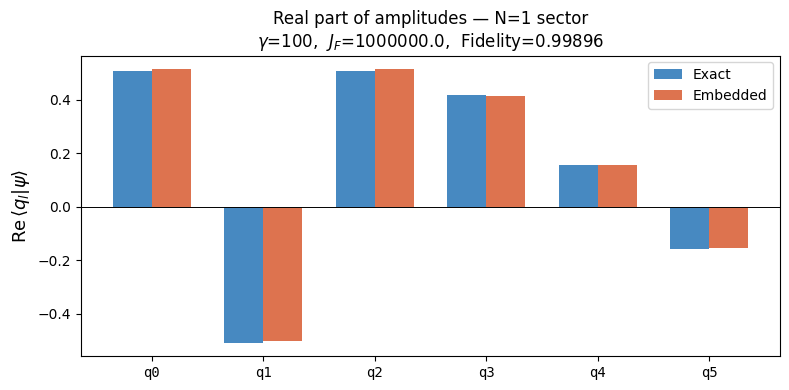

In [131]:
# === Real part only + fidelity (no prenormalization) ===

fidelity = np.abs(np.dot(np.conj(exact_amps), emb_amps)) ** 2
print(f"Fidelity (raw, includes norm loss): {fidelity:.6f}")
print(f"Norm of projected embedded state:   {np.sqrt(np.sum(np.abs(emb_amps)**2)):.6f}")

# --- Plot: real part only ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(logical_qubits)
w = 0.35
labels = [f"q{l}" for l in range(logical_qubits)]
CLR_E = "#2775b6"
CLR_M = "#d85a30"

ax.bar(x - w / 2, exact_amps.real, w, color=CLR_E, alpha=0.85, label="Exact")
ax.bar(x + w / 2, emb_amps.real, w, color=CLR_M, alpha=0.85, label="Embedded")
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle q_l|\psi\rangle$", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontfamily="monospace")
ax.legend()
ax.set_title(
    f"Real part of amplitudes — N=1 sector\n"
    f"$\\gamma$={gamma},  $J_F$={J_F},  Fidelity={fidelity:.5f}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("wavefunction_real.pdf", bbox_inches="tight")
plt.show()

In [132]:
print(np.sum(np.abs(exact_amps) ** 2))  # should be ~1
print(np.sum(np.abs(emb_amps) ** 2))  # how much norm in one-hot sector
print(np.dot(np.conj(exact_amps), emb_amps))  # raw overlap before squaring

1.0
0.9991070679757289
(0.9994777577483234+0j)


In [40]:
for l, chain in chains.items():
    print(f"logical q{l}: chain {chain}, length {len(chain)}")

logical q0: chain [0, 1], length 2
logical q1: chain [2], length 1
logical q2: chain [3], length 1
logical q3: chain [4], length 1
logical q4: chain [5, 6], length 2
logical q5: chain [7], length 1


In [28]:
print("inter_edges:", inter_edges)
print("chains:", chains)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    print(f"  edge ({u},{v}): logical ({lu},{lv})")

inter_edges: [(0, 2), (0, 3), (1, 4), (1, 5), (1, 7), (2, 3), (2, 4), (2, 5), (2, 7), (3, 4), (3, 5), (3, 7), (4, 6), (4, 7), (6, 7)]
chains: {0: [0, 1], 1: [2], 2: [3], 3: [4], 4: [5, 6], 5: [7]}
  edge (0,2): logical (0,1)
  edge (0,3): logical (0,2)
  edge (1,4): logical (0,3)
  edge (1,5): logical (0,4)
  edge (1,7): logical (0,5)
  edge (2,3): logical (1,2)
  edge (2,4): logical (1,3)
  edge (2,5): logical (1,4)
  edge (2,7): logical (1,5)
  edge (3,4): logical (2,3)
  edge (3,5): logical (2,4)
  edge (3,7): logical (2,5)
  edge (4,6): logical (3,4)
  edge (4,7): logical (3,5)
  edge (6,7): logical (4,5)
